Analysis 

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../src"))

from models.black_scholes import black_scholes_price
from models.binomial import binomial_price
from models.monte_carlo import monte_carlo_price
from greeks.greeks import black_scholes_greeks

In [2]:
# Base option parameters
S = 42
K = 40
T = 0.5
r = 0.05
sigma = 0.2
option_type = "put"

# Numerical model settings
steps = 100
simulations = 100000

In [3]:
bs_price = black_scholes_price(option_type, S, K, T, r, sigma)
bin_price = binomial_price(option_type, S, K, T, r, sigma, steps)
mc_price = monte_carlo_price(option_type, S, K, T, r, sigma, simulations, seed=42)

print(f"Black-Scholes Price: {bs_price:.4f}")
print(f"Binomial Price:      {bin_price:.4f}")
print(f"Monte Carlo Price:   {mc_price:.4f}")

Black-Scholes Price: 1.0929
Binomial Price:      1.0958
Monte Carlo Price:   1.0932


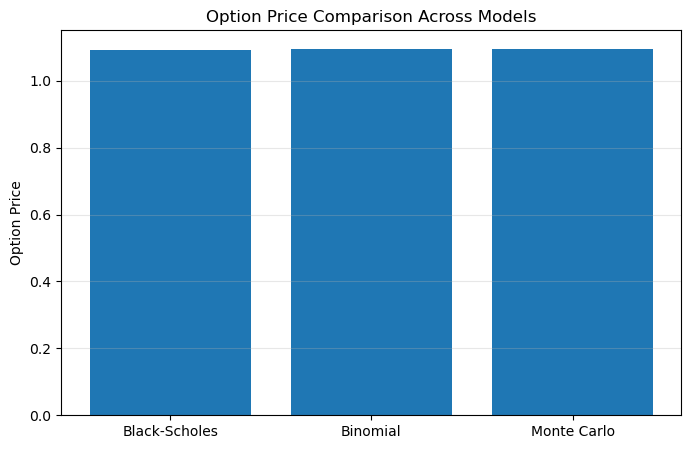

In [4]:
model_names = ["Black-Scholes", "Binomial", "Monte Carlo"]
model_prices = [bs_price, bin_price, mc_price]

plt.figure(figsize=(8, 5))
plt.bar(model_names, model_prices)
plt.ylabel("Option Price")
plt.title("Option Price Comparison Across Models")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [5]:
step_values = [1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]
binomial_prices = []

for n in step_values:
    price = binomial_price(option_type, S, K, T, r, sigma, n)
    binomial_prices.append(price)

bs_reference = black_scholes_price(option_type, S, K, T, r, sigma)

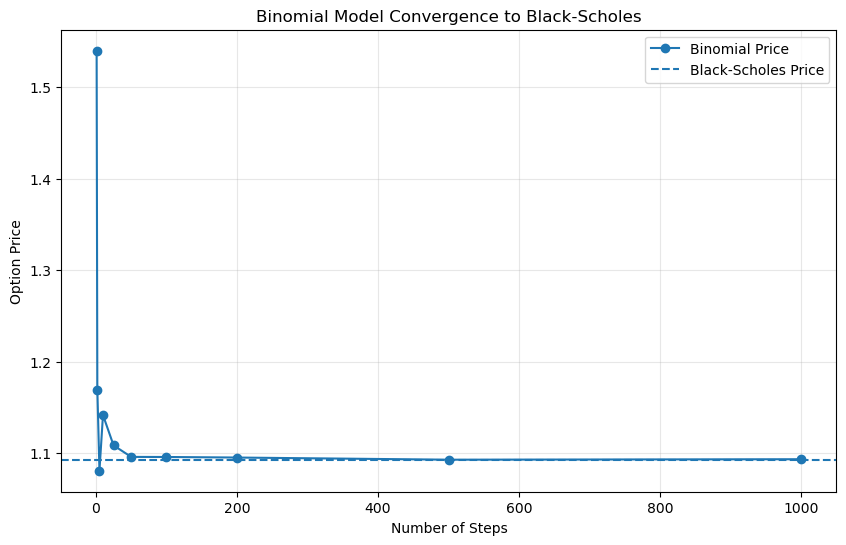

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(step_values, binomial_prices, marker='o', label="Binomial Price")
plt.axhline(bs_reference, linestyle='--', label="Black-Scholes Price")
plt.xlabel("Number of Steps")
plt.ylabel("Option Price")
plt.title("Binomial Model Convergence to Black-Scholes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
simulation_values = [100, 500, 1000, 5000, 10000, 50000, 100000, 200000]
mc_prices = []

for sims in simulation_values:
    price = monte_carlo_price(option_type, S, K, T, r, sigma, sims, seed=42)
    mc_prices.append(price)

bs_reference = black_scholes_price(option_type, S, K, T, r, sigma)

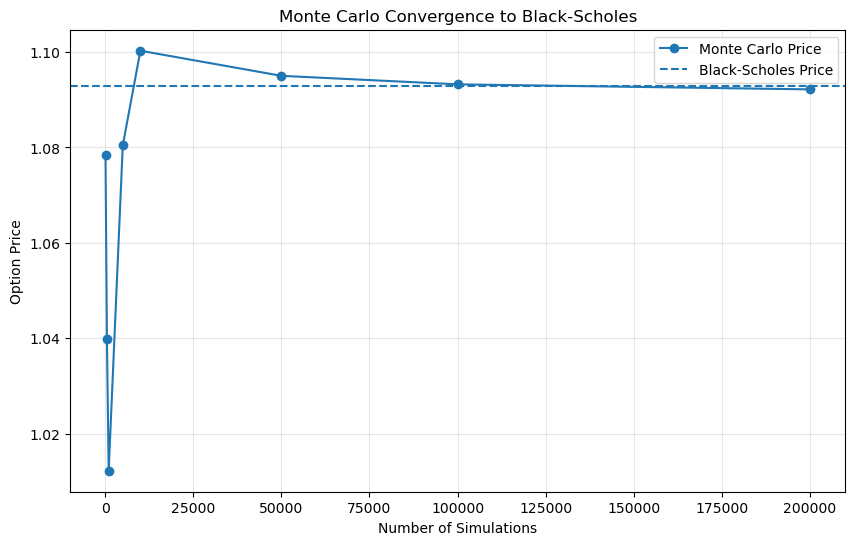

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(simulation_values, mc_prices, marker='o', label="Monte Carlo Price")
plt.axhline(bs_reference, linestyle='--', label="Black-Scholes Price")
plt.xlabel("Number of Simulations")
plt.ylabel("Option Price")
plt.title("Monte Carlo Convergence to Black-Scholes")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
stock_prices = np.linspace(20, 60, 100)

deltas = []
gammas = []
vegas = []
thetas = []
rhos = []

for stock in stock_prices:
    delta, theta, rho, gamma, vega = black_scholes_greeks(option_type, stock, K, T, r, sigma)
    deltas.append(delta)
    gammas.append(gamma)
    vegas.append(vega)
    thetas.append(theta)
    rhos.append(rho)

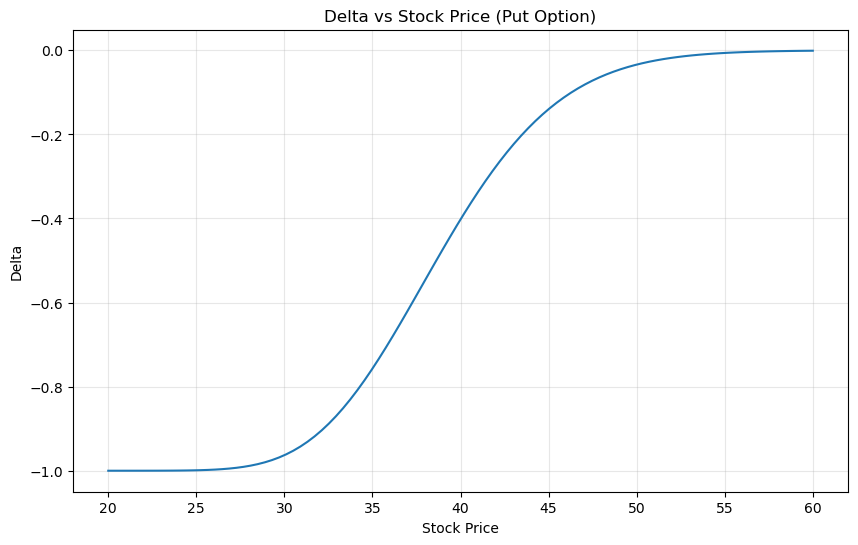

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(stock_prices, deltas)
plt.xlabel("Stock Price")
plt.ylabel("Delta")
plt.title(f"Delta vs Stock Price ({option_type.capitalize()} Option)")
plt.grid(True, alpha=0.3)
plt.show()

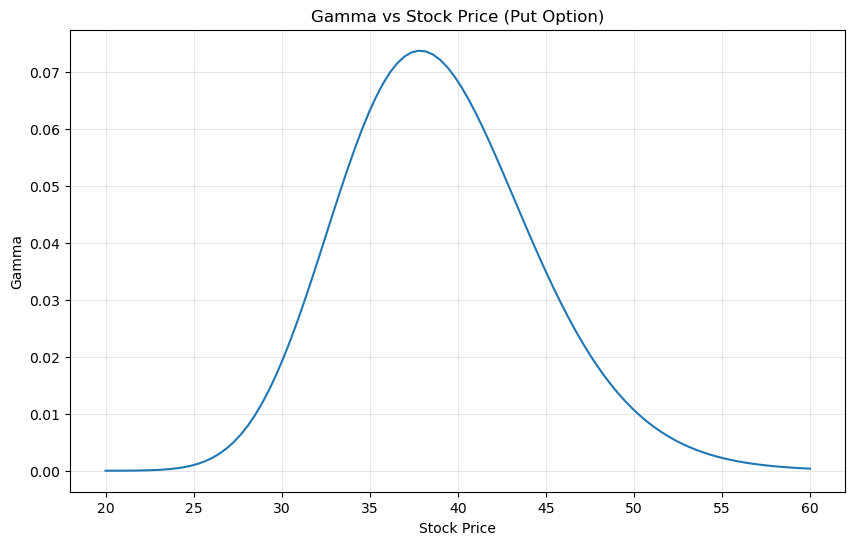

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(stock_prices, gammas)
plt.xlabel("Stock Price")
plt.ylabel("Gamma")
plt.title(f"Gamma vs Stock Price ({option_type.capitalize()} Option)")
plt.grid(True, alpha=0.3)
plt.show()

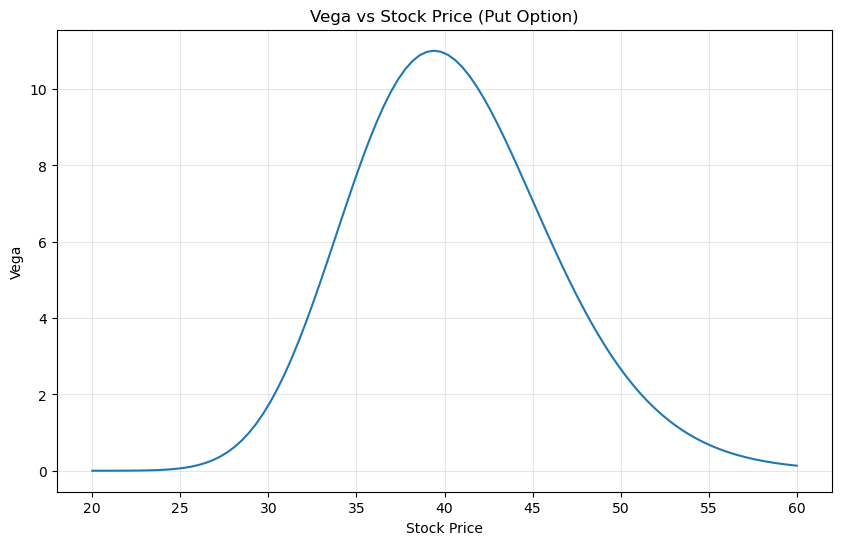

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(stock_prices, vegas)
plt.xlabel("Stock Price")
plt.ylabel("Vega")
plt.title(f"Vega vs Stock Price ({option_type.capitalize()} Option)")
plt.grid(True, alpha=0.3)
plt.show()

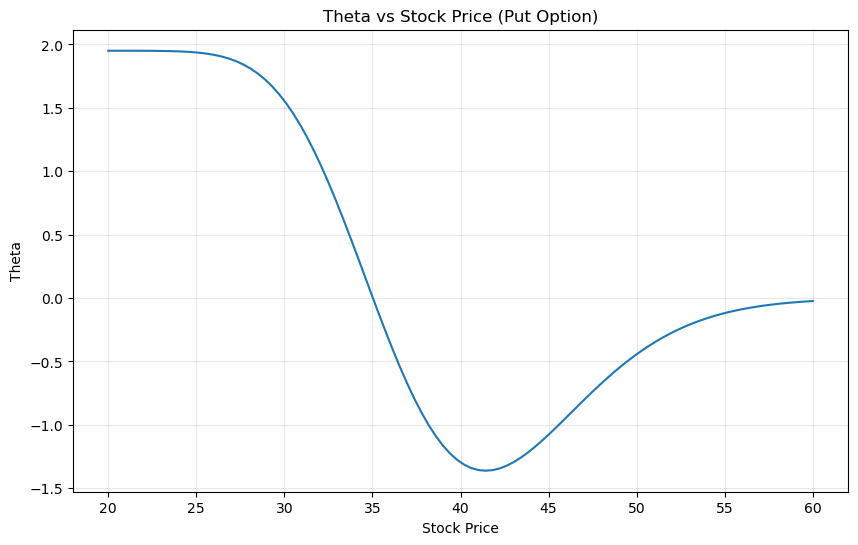

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(stock_prices, thetas)
plt.xlabel("Stock Price")
plt.ylabel("Theta")
plt.title(f"Theta vs Stock Price ({option_type.capitalize()} Option)")
plt.grid(True, alpha=0.3)
plt.show()

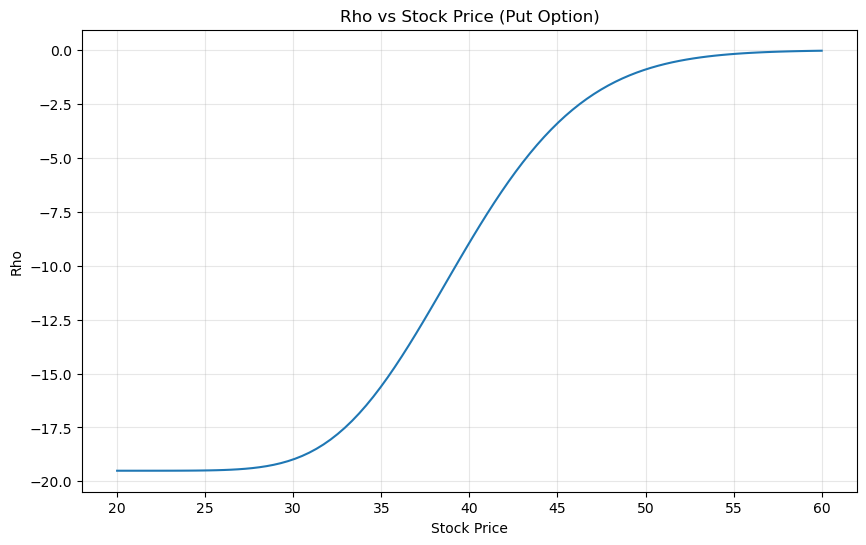

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(stock_prices, rhos)
plt.xlabel("Stock Price")
plt.ylabel("Rho")
plt.title(f"Rho vs Stock Price ({option_type.capitalize()} Option)")
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
stock_range = np.linspace(0, 80, 200)

call_payoff = np.maximum(stock_range - K, 0)
put_payoff = np.maximum(K - stock_range, 0)

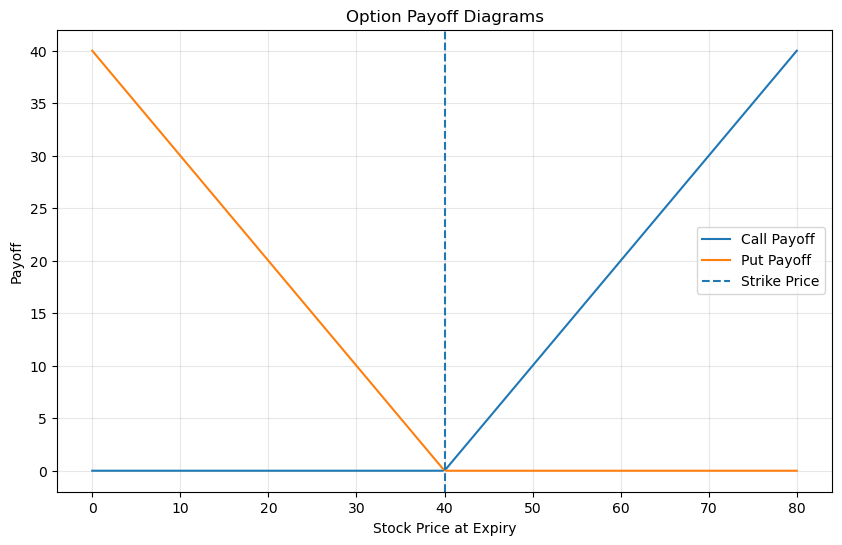

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(stock_range, call_payoff, label="Call Payoff")
plt.plot(stock_range, put_payoff, label="Put Payoff")
plt.axvline(K, linestyle='--', label="Strike Price")
plt.xlabel("Stock Price at Expiry")
plt.ylabel("Payoff")
plt.title("Option Payoff Diagrams")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

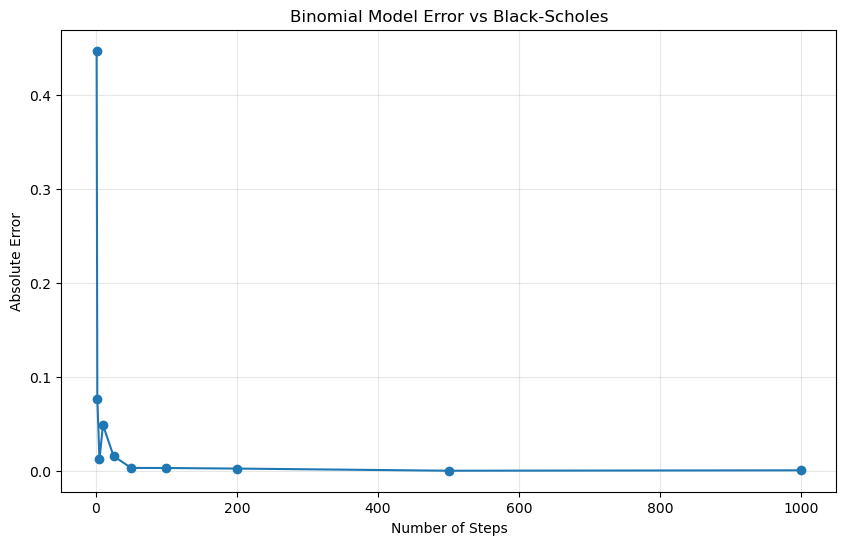

In [18]:
binomial_errors = [abs(price - bs_reference) for price in binomial_prices]

plt.figure(figsize=(10, 6))
plt.plot(step_values, binomial_errors, marker='o')
plt.xlabel("Number of Steps")
plt.ylabel("Absolute Error")
plt.title("Binomial Model Error vs Black-Scholes")
plt.grid(True, alpha=0.3)
plt.show()

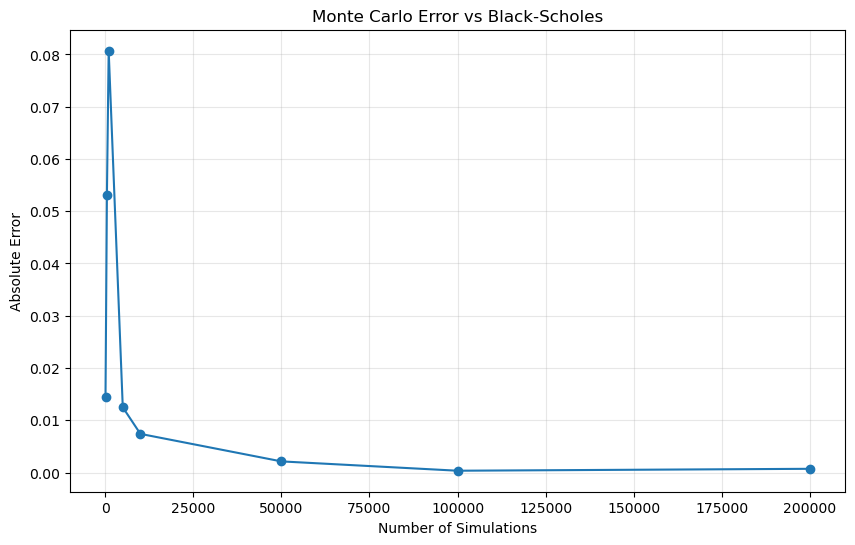

In [19]:
mc_errors = [abs(price - bs_reference) for price in mc_prices]

plt.figure(figsize=(10, 6))
plt.plot(simulation_values, mc_errors, marker='o')
plt.xlabel("Number of Simulations")
plt.ylabel("Absolute Error")
plt.title("Monte Carlo Error vs Black-Scholes")
plt.grid(True, alpha=0.3)
plt.show()